## Individuell inlämningsuppgift – Deep Learning

# Marcus Bäckström


In [1]:
# Grundläggande bibliotek
import time

import os
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)
train_dir = "Data/train"
test_dir = "Data/test"

In [2]:
def load_images_from_folder(dir, image_size=(48, 48), max_per_class = None ):

    X = []
    y = []
    class_names = sorted(os.listdir(dir))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)

        if  max_per_class is not None:
            images = images[:max_per_class]

        for img_file in images:
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert("L") # Convert to grayscale in case they are not grayscale.
                img = img.resize(image_size)
                X.append(np.array(img))
                y.append(label)
            except:
                pass
    


    return  np.array(X), np.array(y), class_names

In [3]:
def plot_image_grid(X,y, class_names, n_images=25, random_state=42, afigsize=(12, 12) ):

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images) ) )

    plt.figure(figsize=afigsize)

    for plot_index, image_index in enumerate(indices):
        
        plt.subplot(grid_size, grid_size, plot_index + 1)

        plt.imshow(X[image_index], cmap="gray")

        plt.title(class_names[y[image_index] ], fontsize=9 )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
class_names_train = sorted(os.listdir(train_dir))
print(f"Train Klasser : {class_names_train}")
class_names_test = sorted(os.listdir(test_dir))
print(f"Test Klasser : {class_names_test}")

Train Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [17]:
class_distribution_train = pd.DataFrame({
    "train_class_name": class_names_train,
    "count": [len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names_train]
})

class_distribution_test = pd.DataFrame({
    "test_class_name": class_names_test,
    "count": [len(os.listdir(os.path.join(test_dir, cls))) for cls in class_names_test]
})

display(class_distribution_train)
display(class_distribution_test)

,train_class_name,count
0,angry,3995
1,disgust,436
2,fear,4097
3,happy,7215
4,neutral,4965
5,sad,4830
6,surprise,3171


,test_class_name,count
0,angry,958
1,disgust,111
2,fear,1024
3,happy,1774
4,neutral,1233
5,sad,1247
6,surprise,831


In [20]:
print("Totalt antal träningsbilder:", class_distribution_train["count"].sum())
print("Totalt antal testbilder:", class_distribution_test["count"].sum())


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


In [ ]:

X_train_full, y_train_full, class_names = load_images_from_folder(
    train_dir, 
    max_per_class=300
)

print(f"X_train_full Shape : {X_train_full.shape}")
print(f"y_train_full Shape : {y_train_full.shape}")
print(f"Class Names : {class_names}")

X_train_full Shape : (2100, 48, 48)
y_train_full Shape : (2100,)
Class Names : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,angry,300
1,1,disgust,300
2,2,fear,300
3,3,happy,300
4,4,neutral,300
5,5,sad,300
6,6,surprise,300


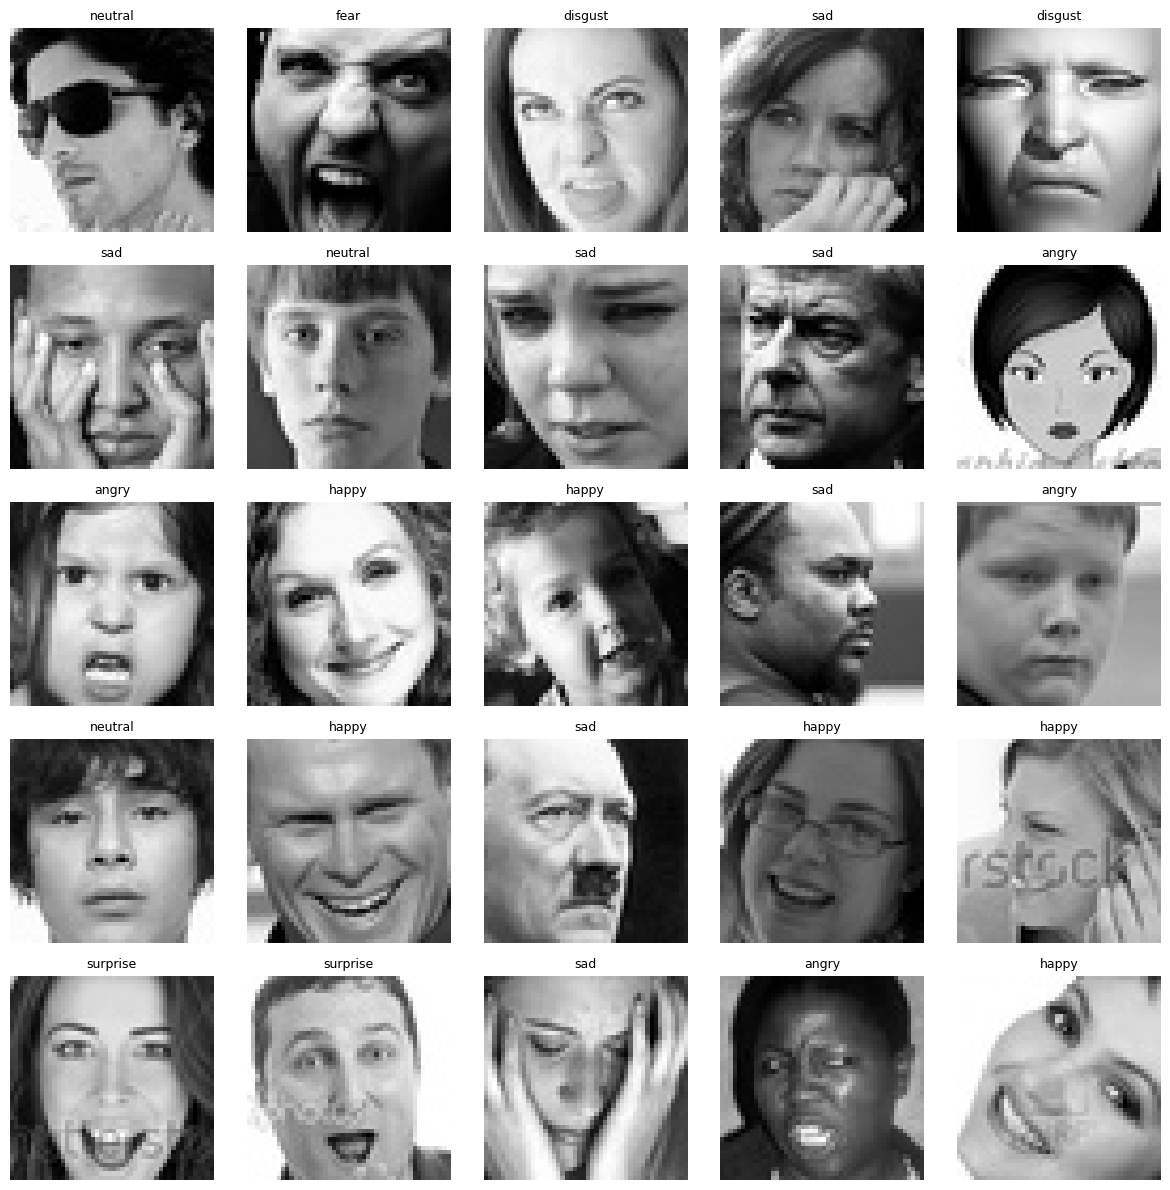

In [10]:
plot_image_grid(
    X=X_train_full,
    y=y_train_full,
    class_names=class_names,
    n_images=25
)